# 07 - Baseline con Random Forest

Construiremos un modelo de clasificación binaria con **Random Forest** manteniendo la misma preparación de datos, particiones y métricas utilizadas en los modelos anteriores.

Random Forest combina múltiples árboles de decisión entrenados sobre diferentes muestras y subconjuntos de variables. La predicción final se obtiene agregando las predicciones de esos árboles, lo que normalmente reduce la varianza respecto a un único árbol de decisión.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)


## 1. Carga y preparación


In [3]:
DATA_FILE = Path("../data/raw/cardio_train.csv")
df = pd.read_csv(DATA_FILE, sep=";")

valid_mask = (
    df["height"].between(120, 220)
    & df["weight"].between(30, 200)
    & df["ap_hi"].between(70, 250)
    & df["ap_lo"].between(40, 150)
    & (df["ap_hi"] > df["ap_lo"])
)

df = df.loc[valid_mask].copy()

df["age_years"] = df["age"] / 365.25
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

df_model = df.drop(columns=["id", "age"])

X = df_model.drop(columns=["cardio","cholesterol", "gluc"])
y = df_model["cardio"]

print(X.shape, y.shape)

(68610, 10) (68610,)


## 2. Train / Validation / Test

Se conserva exactamente la misma división 70 % / 15 % / 15 % y el mismo `random_state=42` para que los resultados sean comparables con los otros modelos.


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

for name, X_part, y_part in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test)
]:
    print(
        f"{name}: {len(X_part):,} observaciones | "
        f"cardio=1: {y_part.mean()*100:.2f}%"
    )

Train: 48,027 observaciones | cardio=1: 49.47%
Validation: 10,291 observaciones | cardio=1: 49.47%
Test: 10,292 observaciones | cardio=1: 49.47%


## 3. Preprocesador

Random Forest no necesita que las variables continuas estén estandarizadas. Los árboles dividen los datos mediante umbrales y, por tanto, el cambio de escala no altera la lógica de las particiones.

Se mantiene `OneHotEncoder` para `gender` y se dejan pasar directamente las variables continuas y binarias.


In [5]:
continuous_features = [
    "height", "weight", "ap_hi",
    "ap_lo", "age_years", "bmi"
]

ordinal_features = []
binary_features = ["smoke", "alco", "active"]
categorical_features = ["gender"]

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", "passthrough", continuous_features),
        (
            "gender",
            OneHotEncoder(
                drop=None,
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        ("ordinal", "passthrough", ordinal_features),
        ("binary", "passthrough", binary_features),
    ]
)


## 4. Crear Pipeline y modelo

El `Pipeline` conecta automáticamente el preprocesamiento y el entrenamiento, evitando aplicar transformaciones de forma diferente entre Train y Validation.

Esta configuración se utiliza como **baseline de Random Forest**, no como una optimización final. Se usan 300 árboles para obtener una estimación estable, `random_state=42` para reproducibilidad y `n_jobs=-1` para utilizar los núcleos disponibles del procesador.


In [6]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('gender', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, de

## 5. Entrenar con Train


In [7]:
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['gender','height','weight',...,'active','age_years','bmi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('gender', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

## 6. Predicciones sobre Validation


In [8]:
y_val_pred = pipeline.predict(X_val)
y_val_proba = pipeline.predict_proba(X_val)[:, 1]

print("Clases predichas:")
print(y_val_pred[:10])

print("\nProbabilidades cardio=1:")
print(y_val_proba[:10])


Clases predichas:
[1 1 0 0 1 0 1 0 0 1]

Probabilidades cardio=1:
[0.55       0.74       0.38333333 0.31       0.78       0.41333333
 0.70666667 0.39       0.23666667 0.79666667]


`predict()` devuelve la clase estimada (`0` o `1`).

`predict_proba()` devuelve las probabilidades estimadas para ambas clases. `[:, 1]` selecciona la probabilidad asignada a `cardio=1`. En Random Forest esta probabilidad se obtiene agregando las probabilidades de los árboles individuales.


## 7. Métricas


In [9]:
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

metrics_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall / Sensitivity",
        "F1-score",
        "ROC-AUC"
    ],
    "Valor": [accuracy, precision, recall, f1, roc_auc]
})

metrics_df.round(4)

,Métrica,Valor
0,Accuracy,0.6948
1,Precision,0.6926
2,Recall / Sensitivity,0.6887
3,F1-score,0.6906
4,ROC-AUC,0.7521


- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** de los predichos positivos, cuántos son realmente positivos.
- **Recall:** de los positivos reales, cuántos detectamos.
- **F1:** balance entre Precision y Recall.
- **ROC-AUC:** capacidad de discriminación a través de distintos umbrales.

## 8. Matriz de confusión


TN: 3644
FP: 1556
FN: 1585
TP: 3506


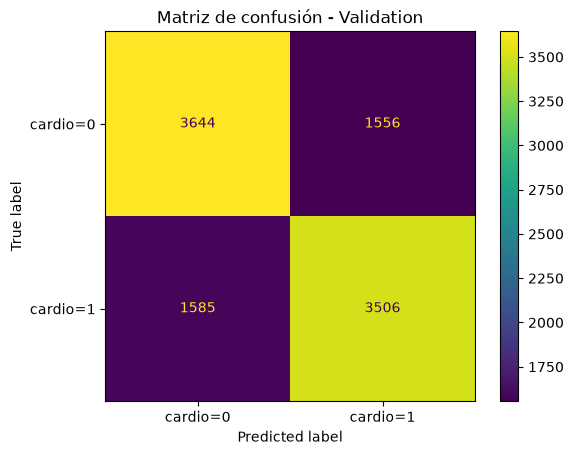

In [10]:
cm = confusion_matrix(y_val, y_val_pred)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["cardio=0", "cardio=1"]
).plot()

plt.title("Matriz de confusión - Validation")
plt.show()

## 9. Classification report


In [11]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["cardio=0", "cardio=1"],
        digits=4
    )
)

              precision    recall  f1-score   support

    cardio=0     0.6969    0.7008    0.6988      5200
    cardio=1     0.6926    0.6887    0.6906      5091

    accuracy                         0.6948     10291
   macro avg     0.6947    0.6947    0.6947     10291
weighted avg     0.6948    0.6948    0.6948     10291



## 10. Curva ROC


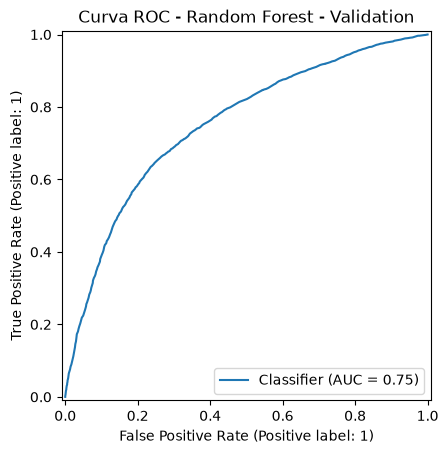

In [12]:
RocCurveDisplay.from_predictions(
    y_val,
    y_val_proba
)

plt.title("Curva ROC - Random Forest - Validation")
plt.show()


## 11. Importancia de variables

Random Forest permite calcular la importancia relativa de las variables a partir de la reducción de impureza producida por las divisiones realizadas por los árboles.

Esta medida ayuda a interpretar qué variables utiliza más el modelo, pero **no implica causalidad** y puede favorecer variables con mayor cantidad de posibles puntos de corte.


In [13]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df


,feature,importance
4,continuous__age_years,0.296519
2,continuous__ap_hi,0.174295
5,continuous__bmi,0.170237
1,continuous__weight,0.119968
0,continuous__height,0.113730
3,continuous__ap_lo,0.080939
10,binary__active,0.012711
8,binary__smoke,0.008592
6,gender__gender_1,0.007948
7,gender__gender_2,0.007895


## 12. Visualización de importancia de variables


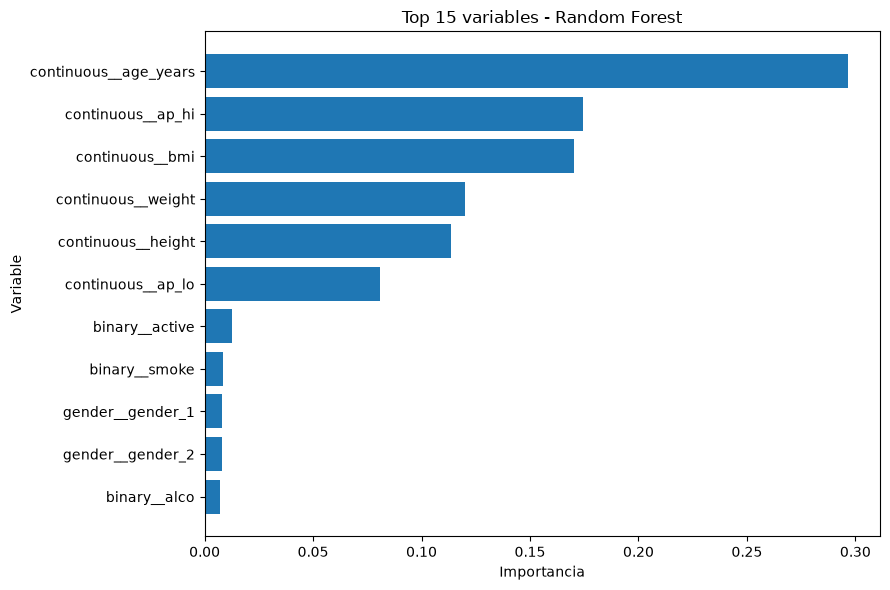

In [14]:
top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 15 variables - Random Forest")
plt.tight_layout()
plt.show()


## 13. Comparación Train vs Validation

Random Forest puede alcanzar un desempeño muy alto sobre Train si los árboles crecen con suficiente profundidad. Comparar Train y Validation permite detectar una posible brecha de generalización.

Una diferencia considerable entre ambos resultados puede indicar sobreajuste y justificar posteriormente el ajuste de hiperparámetros como `max_depth`, `min_samples_split`, `min_samples_leaf` o `max_features`.


In [15]:
train_pred = pipeline.predict(X_train)
train_proba = pipeline.predict_proba(X_train)[:, 1]

train_metrics = {
    "Accuracy": accuracy_score(y_train, train_pred),
    "Precision": precision_score(y_train, train_pred),
    "Recall": recall_score(y_train, train_pred),
    "F1-score": f1_score(y_train, train_pred),
    "ROC-AUC": roc_auc_score(y_train, train_proba)
}

validation_metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}

comparison_df = pd.DataFrame({
    "Train": train_metrics,
    "Validation": validation_metrics
})

comparison_df["Diferencia"] = comparison_df["Train"] - comparison_df["Validation"]
comparison_df.round(4)


,Train,Validation,Diferencia
Accuracy,0.9998,0.6948,0.3051
Precision,0.9999,0.6926,0.3073
Recall,0.9998,0.6887,0.3111
F1-score,0.9998,0.6906,0.3092
ROC-AUC,1.0000,0.7521,0.2479


## 14. Parámetros principales del modelo

En este baseline solo fijamos `n_estimators`, `random_state` y `n_jobs`. Los demás hiperparámetros conservan los valores por defecto de `RandomForestClassifier`.

Los principales parámetros que pueden evaluarse posteriormente son:

- `n_estimators`: número de árboles del bosque.
- `criterion`: función usada para medir la calidad de las divisiones.
- `max_depth`: profundidad máxima de cada árbol.
- `min_samples_split`: mínimo de observaciones necesarias para dividir un nodo.
- `min_samples_leaf`: mínimo de observaciones que debe conservar una hoja.
- `max_features`: cantidad de variables consideradas en cada división.
- `class_weight`: ponderación de las clases.

Estos parámetros deben ajustarse usando Train/Validation o validación cruzada, sin utilizar Test para seleccionar la configuración.


# 15. Siguiente paso

Este notebook proporciona el **baseline de Random Forest** utilizando la misma preparación y las mismas particiones de datos de los modelos anteriores.

El conjunto **Test continúa reservado**. La comparación y el ajuste de hiperparámetros deben realizarse con Train y Validation. Solo después de seleccionar una configuración final debe utilizarse Test para obtener una estimación final de desempeño.
